# Risk Analysis

This notebook builds on the population trend calculation from the previous step.

The previous notebook created one consistent population-level risk classification:

- **Critical decline**
- **High decline**
- **Moderate decline**
- **Stable / near stable**
- **Increase**

In this notebook, the same classification is reused without redefining the logic. This keeps the project consistent and avoids introducing multiple competing definitions of risk.

## Main research questions

1. Which vertebrate classes contain the highest share of declining populations?
2. Which ecosystems have the highest proportion of high-risk populations?
3. Which regions contain more high-risk populations?
4. Which well-monitored species show consistently negative population trends?

The main unit of analysis remains the **population**. Species-level summaries are included only as a supplementary perspective.

## 1. Load libraries and processed trend data

This notebook uses the processed file created in `01_population_trend_calculation.ipynb`.

The input file should already contain:

- `Log_Trend`
- `Risk_Category`
- `High_Risk`

In [1]:
# Import core libraries for data handling and visualization.
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display all dataframe columns in notebook outputs.
pd.set_option("display.max_columns", None)

# Use a clean default plotting style.
sns.set_theme(style="whitegrid")

# Define project paths used in this notebook.
DATA_PATH = Path("../data/processed/lpd_population_trends_with_risk.csv")
FIGURE_DIR = Path("../outputs/figures")
OUTPUT_DIR = Path("../outputs")

# Create output folders if they do not already exist.
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load the population-level trend dataset with risk categories.
trend_data = pd.read_csv(DATA_PATH)

# Preview the first rows to confirm that the dataset loaded correctly.
trend_data.head()

,ID,Binomial,Class,Region,System,Latitude,Longitude,First_Year,Last_Year,First_Population,Last_Population,Observations,Years_Monitored,Log_Trend,Risk_Category,High_Risk
0,1,Balearica_regulorum,Aves,Africa,Terrestrial,-0.07889,31.13306,1985,2002,3.7,10.8,3,17,0.920537,Increase,False
1,2,Acrocephalus_sechellensis,Aves,Africa,Terrestrial,-4.33333,55.66667,1958,1987,30.0,430.0,3,29,2.632121,Increase,False
2,3,Copsychus_sechellarum,Aves,Africa,Terrestrial,-4.58333,55.66667,1977,1990,38.0,21.0,6,13,-0.572519,High decline,True
3,4,Copsychus_sechellarum,Aves,Africa,Terrestrial,-4.58333,55.93333,1976,1990,46.0,22.0,14,14,-0.714653,High decline,True
4,5,Falco_punctatus,Aves,Africa,Terrestrial,-20.30000,57.58333,1973,1997,1.0,61.0,25,24,3.433987,Increase,False


## 2. Validate required columns

Before starting the analysis, the notebook checks that all required columns are available. This step helps catch problems early, for example if the previous notebook saved an older version of the processed file.

In [2]:
# List the columns required for this risk analysis.
required_cols = [
    "ID",
    "Class",
    "Binomial",
    "Region",
    "System",
    "First_Year",
    "Last_Year",
    "First_Population",
    "Last_Population",
    "Years_Monitored",
    "Log_Trend",
    "Risk_Category",
    "High_Risk",
]

# Identify any required columns that are missing from the loaded dataset.
missing_cols = [col for col in required_cols if col not in trend_data.columns]

# Stop the notebook with a clear error message if any required columns are missing.
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# Show dataset shape and confirm that all required columns are present.
print(f"Dataset shape: {trend_data.shape}")
print("All required columns are present.")

Dataset shape: (21284, 16)
All required columns are present.


## 3. Reapply risk category order

The risk categories are not recalculated here. They were created in the previous notebook.

Here, they are only converted to an ordered categorical variable so that tables and plots always follow the same order from strongest decline to increase.

In [3]:
# Define one consistent order for the population-level risk categories.
risk_order = [
    "Critical decline",
    "High decline",
    "Moderate decline",
    "Stable / near stable",
    "Increase",
]

# Convert Risk_Category into an ordered categorical variable for consistent sorting and plotting.
trend_data["Risk_Category"] = pd.Categorical(
    trend_data["Risk_Category"],
    categories=risk_order,
    ordered=True,
)

# Recreate the High_Risk flag from the already existing Risk_Category column.
# This keeps the definition explicit and consistent across notebooks.
trend_data["High_Risk"] = trend_data["Risk_Category"].isin(
    ["Critical decline", "High decline"]
)

# Display the number of populations in each risk category.
risk_counts = trend_data["Risk_Category"].value_counts().reindex(risk_order)
risk_counts

Risk_Category
Critical decline        4062
High decline            2012
Moderate decline        2790
Stable / near stable    5008
Increase                7412
Name: count, dtype: int64

## 4. Overall risk distribution

This section gives a first overview of how monitored populations are distributed across the five risk categories.

This answers the broad question:

**How many monitored populations show decline, stability, or increase?**

In [4]:
# Calculate the number and share of populations in each risk category.
overall_risk_summary = (
    trend_data["Risk_Category"]
    .value_counts()
    .reindex(risk_order)
    .rename_axis("Risk_Category")
    .reset_index(name="Population_Count")
)

overall_risk_summary["Share"] = (
    overall_risk_summary["Population_Count"]
    / overall_risk_summary["Population_Count"].sum()
)

# Display the summary table.
overall_risk_summary

,Risk_Category,Population_Count,Share
0,Critical decline,4062,0.190848
1,High decline,2012,0.094531
2,Moderate decline,2790,0.131084
3,Stable / near stable,5008,0.235294
4,Increase,7412,0.348243


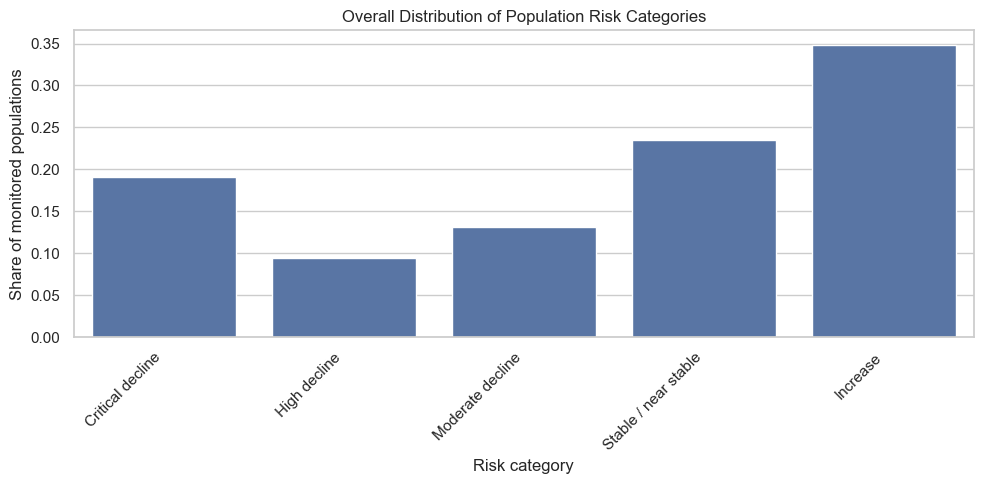

In [5]:
# Create a bar plot showing the overall distribution of population risk categories.
plt.figure(figsize=(10, 5))

sns.barplot(
    data=overall_risk_summary,
    x="Risk_Category",
    y="Share",
    order=risk_order,
)

plt.title("Overall Distribution of Population Risk Categories")
plt.xlabel("Risk category")
plt.ylabel("Share of monitored populations")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

# Save the figure for use in the final report or presentation.
plt.savefig(FIGURE_DIR / "overall_risk_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Risk patterns by vertebrate class

This section compares risk categories across vertebrate classes.

It answers:

**Which vertebrate classes contain the highest share of high-risk populations?**

A high-risk population is defined as a population classified as either **Critical decline** or **High decline**.

In [6]:
# Count populations by vertebrate class and risk category.
class_risk_summary = (
    trend_data
    .groupby(["Class", "Risk_Category"], observed=True)
    .size()
    .reset_index(name="Population_Count")
)

# Calculate the total number of monitored populations in each class.
class_totals = (
    trend_data
    .groupby("Class", observed=True)
    .size()
    .reset_index(name="Total_Populations")
)

# Merge category counts with class totals and calculate within-class shares.
class_risk_summary = class_risk_summary.merge(class_totals, on="Class")
class_risk_summary["Share"] = (
    class_risk_summary["Population_Count"]
    / class_risk_summary["Total_Populations"]
)

# Display the class-level risk summary.
class_risk_summary.head(20)

,Class,Risk_Category,Population_Count,Total_Populations,Share
0,Actinopteri,Critical decline,668,4847,0.137817
1,Actinopteri,High decline,406,4847,0.083763
2,Actinopteri,Moderate decline,829,4847,0.171034
3,Actinopteri,Stable / near stable,1577,4847,0.325356
4,Actinopteri,Increase,1367,4847,0.282030
5,Amphibia,Critical decline,69,205,0.336585
6,Amphibia,High decline,21,205,0.102439
7,Amphibia,Moderate decline,30,205,0.146341
8,Amphibia,Stable / near stable,32,205,0.156098
9,Amphibia,Increase,53,205,0.258537


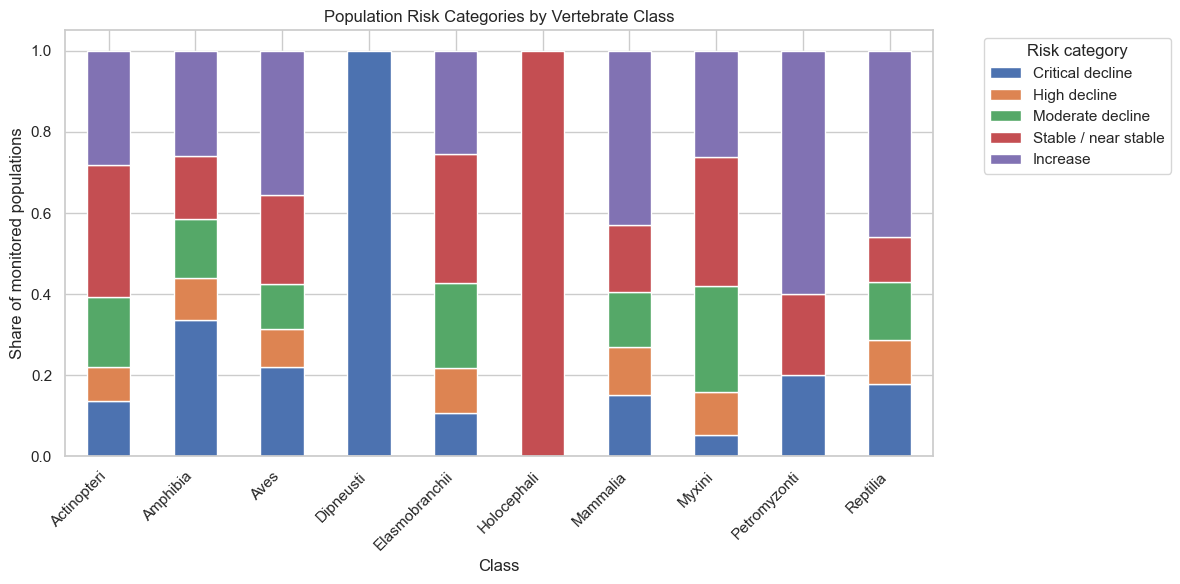

In [7]:
# Reshape the class risk summary into a matrix for stacked bar plotting.
pivot_class_risk = (
    class_risk_summary
    .pivot(index="Class", columns="Risk_Category", values="Share")
    .fillna(0)
)

# Ensure that risk categories appear in the predefined order.
pivot_class_risk = pivot_class_risk[risk_order]

# Create a stacked bar chart showing the composition of risk categories within each class.
ax = pivot_class_risk.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
)

plt.title("Population Risk Categories by Vertebrate Class")
plt.ylabel("Share of monitored populations")
plt.xlabel("Class")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Risk category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

# Save the plot for later use.
plt.savefig(FIGURE_DIR / "risk_categories_by_class.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
# Summarize the share of high-risk populations in each vertebrate class.
class_high_risk_summary = (
    trend_data
    .groupby("Class", observed=True)
    .agg(
        Total_Populations=("ID", "count"),
        High_Risk_Populations=("High_Risk", "sum"),
        Median_Log_Trend=("Log_Trend", "median"),
    )
    .reset_index()
)

# Calculate the proportion of high-risk populations within each class.
class_high_risk_summary["High_Risk_Share"] = (
    class_high_risk_summary["High_Risk_Populations"]
    / class_high_risk_summary["Total_Populations"]
)

# Sort classes from highest to lowest share of high-risk populations.
class_high_risk_summary = class_high_risk_summary.sort_values(
    "High_Risk_Share",
    ascending=False,
)

class_high_risk_summary

,Class,Total_Populations,High_Risk_Populations,Median_Log_Trend,High_Risk_Share
3,Dipneusti,1,1,-2.456736,1.000000
1,Amphibia,205,90,-0.270945,0.439024
2,Aves,12476,3915,0.000000,0.313803
9,Reptilia,373,107,0.000600,0.286863
6,Mammalia,2957,796,0.000000,0.269192
0,Actinopteri,4847,1074,0.000000,0.221580
4,Elasmobranchii,397,87,-0.030893,0.219144
8,Petromyzonti,5,1,1.271884,0.200000
7,Myxini,19,3,0.003363,0.157895
5,Holocephali,4,0,0.020643,0.000000


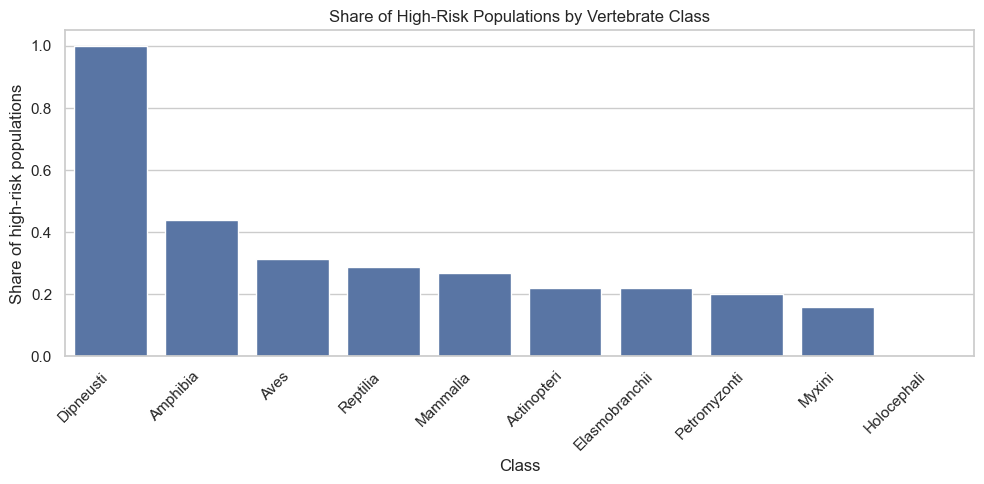

In [9]:
# Create a focused bar plot for the share of high-risk populations by class.
plt.figure(figsize=(10, 5))

sns.barplot(
    data=class_high_risk_summary,
    x="Class",
    y="High_Risk_Share",
)

plt.title("Share of High-Risk Populations by Vertebrate Class")
plt.xlabel("Class")
plt.ylabel("Share of high-risk populations")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

# Save the figure.
plt.savefig(FIGURE_DIR / "high_risk_share_by_class.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Risk patterns by ecosystem system

This section compares risk across ecosystem systems such as freshwater, marine, and terrestrial populations.

It answers:

**Which ecosystem systems contain the highest share of high-risk populations?**

In [10]:
# Summarize total and high-risk populations by ecosystem system.
system_high_risk_summary = (
    trend_data
    .groupby("System", observed=True)
    .agg(
        Total_Populations=("ID", "count"),
        High_Risk_Populations=("High_Risk", "sum"),
        Median_Log_Trend=("Log_Trend", "median"),
    )
    .reset_index()
)

# Calculate the proportion of high-risk populations in each system.
system_high_risk_summary["High_Risk_Share"] = (
    system_high_risk_summary["High_Risk_Populations"]
    / system_high_risk_summary["Total_Populations"]
)

# Sort systems from highest to lowest high-risk share.
system_high_risk_summary = system_high_risk_summary.sort_values(
    "High_Risk_Share",
    ascending=False,
)

system_high_risk_summary

,System,Total_Populations,High_Risk_Populations,Median_Log_Trend,High_Risk_Share
1,Marine,10186,3366,0.0,0.330454
2,Terrestrial,6929,1795,0.0,0.259056
0,Freshwater,4169,913,0.0,0.218997


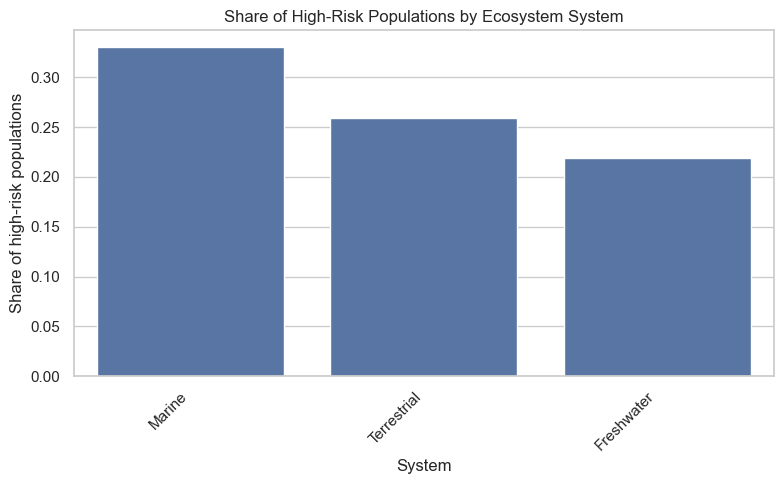

In [11]:
# Create a bar plot comparing high-risk population shares across systems.
plt.figure(figsize=(8, 5))

sns.barplot(
    data=system_high_risk_summary,
    x="System",
    y="High_Risk_Share",
)

plt.title("Share of High-Risk Populations by Ecosystem System")
plt.xlabel("System")
plt.ylabel("Share of high-risk populations")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

# Save the figure.
plt.savefig(FIGURE_DIR / "high_risk_share_by_system.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Risk patterns by region

This section gives a non-map regional overview before the spatial analysis notebook.

It answers:

**Which broad regions contain the highest share of high-risk monitored populations?**

The following notebook will examine these patterns geographically using latitude and longitude.

In [12]:
# Summarize total and high-risk populations by region.
region_high_risk_summary = (
    trend_data
    .groupby("Region", observed=True)
    .agg(
        Total_Populations=("ID", "count"),
        High_Risk_Populations=("High_Risk", "sum"),
        Median_Log_Trend=("Log_Trend", "median"),
    )
    .reset_index()
)

# Calculate the proportion of high-risk populations in each region.
region_high_risk_summary["High_Risk_Share"] = (
    region_high_risk_summary["High_Risk_Populations"]
    / region_high_risk_summary["Total_Populations"]
)

# Sort regions from highest to lowest high-risk share.
region_high_risk_summary = region_high_risk_summary.sort_values(
    "High_Risk_Share",
    ascending=False,
)

region_high_risk_summary

,Region,Total_Populations,High_Risk_Populations,Median_Log_Trend,High_Risk_Share
4,International Waters,154,63,-0.284316,0.409091
7,Oceania,6874,2706,0.000000,0.393657
0,Africa,1577,543,-0.121890,0.344325
2,Asia,966,322,0.000000,0.333333
1,Antarctic,202,47,0.253295,0.232673
6,North America,5731,1228,-0.000082,0.214273
3,Europe,3648,753,0.240171,0.206414
5,Latin America and Caribbean,2132,412,0.000000,0.193246


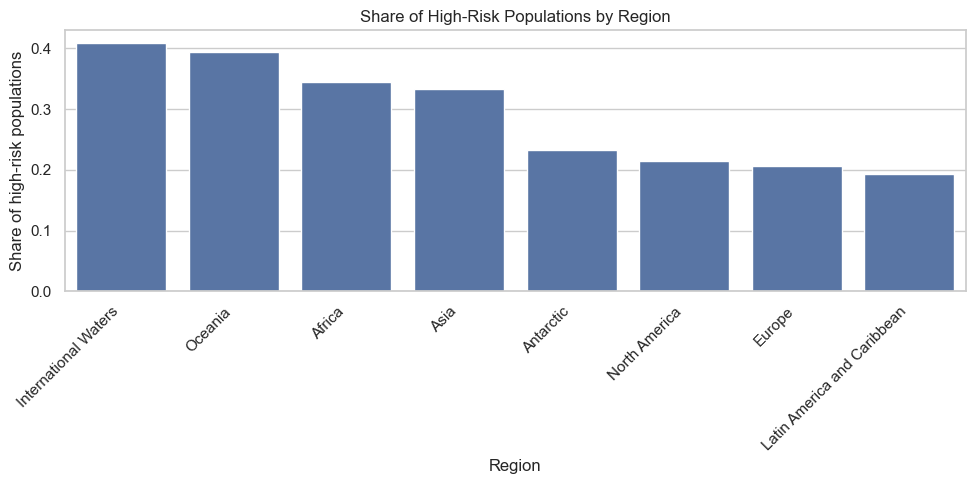

In [13]:
# Create a bar plot comparing high-risk population shares across regions.
plt.figure(figsize=(10, 5))

sns.barplot(
    data=region_high_risk_summary,
    x="Region",
    y="High_Risk_Share",
)

plt.title("Share of High-Risk Populations by Region")
plt.xlabel("Region")
plt.ylabel("Share of high-risk populations")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

# Save the figure.
plt.savefig(FIGURE_DIR / "high_risk_share_by_region.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Combined class and region patterns

This section combines taxonomic and regional dimensions.

It answers:

**Which class-region combinations show the highest share of high-risk populations?**

This is useful because a class may not be equally vulnerable in all regions, and a region may not show the same pattern across all vertebrate classes.

In [14]:
# Summarize high-risk population shares for each class-region combination.
class_region_summary = (
    trend_data
    .groupby(["Class", "Region"], observed=True)
    .agg(
        Total_Populations=("ID", "count"),
        High_Risk_Populations=("High_Risk", "sum"),
        Median_Log_Trend=("Log_Trend", "median"),
    )
    .reset_index()
)

# Calculate the high-risk share for each class-region combination.
class_region_summary["High_Risk_Share"] = (
    class_region_summary["High_Risk_Populations"]
    / class_region_summary["Total_Populations"]
)

# Keep only combinations with enough monitored populations to be interpretable.
class_region_filtered = class_region_summary[
    class_region_summary["Total_Populations"] >= 20
].copy()

# Show the strongest class-region risk patterns.
class_region_filtered.sort_values(
    ["High_Risk_Share", "Total_Populations"],
    ascending=[False, False],
).head(20)

,Class,Region,Total_Populations,High_Risk_Populations,Median_Log_Trend,High_Risk_Share
9,Amphibia,Asia,28,22,-1.278653,0.785714
4,Actinopteri,International Waters,103,48,-0.395896,0.466019
11,Amphibia,Latin America and Caribbean,58,27,-0.301301,0.465517
22,Elasmobranchii,Africa,33,14,-0.375388,0.424242
20,Aves,Oceania,5793,2366,0.000000,0.408424
2,Actinopteri,Asia,199,80,-0.182322,0.402010
31,Mammalia,Africa,686,260,-0.116874,0.379009
10,Amphibia,Europe,22,8,-0.241968,0.363636
36,Mammalia,Latin America and Caribbean,96,34,-0.117644,0.354167
14,Aves,Africa,643,215,-0.145258,0.334370


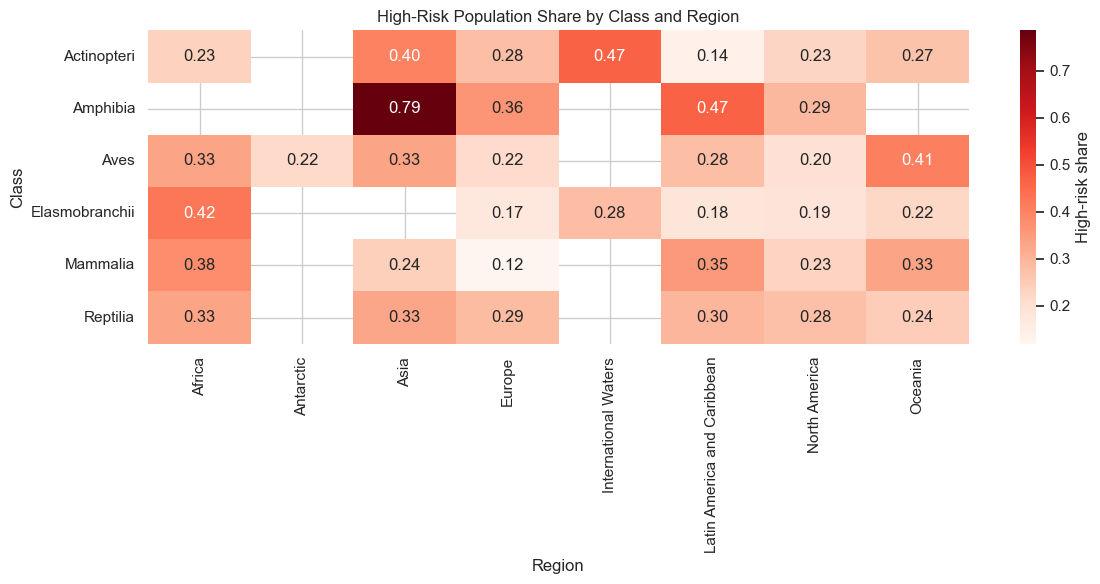

In [15]:
# Prepare a heatmap matrix of high-risk shares by class and region.
class_region_heatmap = (
    class_region_filtered
    .pivot(index="Class", columns="Region", values="High_Risk_Share")
)

# Plot the class-region heatmap.
plt.figure(figsize=(12, 6))

sns.heatmap(
    class_region_heatmap,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    cbar_kws={"label": "High-risk share"},
)

plt.title("High-Risk Population Share by Class and Region")
plt.xlabel("Region")
plt.ylabel("Class")
plt.tight_layout()

# Save the figure.
plt.savefig(FIGURE_DIR / "high_risk_share_class_region_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. Supplementary species-level summary

The main project story is population-based because the Living Planet Database is structured around monitored populations.

However, a supplementary species-level summary can help identify species for which many monitored populations show strong decline.

To keep the analysis consistent, this section does **not** create a separate species risk category. Instead, species are summarized using the same population-level risk classification:

- number of monitored populations
- number of high-risk populations
- share of high-risk populations
- median log trend

Only species with at least 20 monitored populations are highlighted to reduce the influence of species represented by only a few populations.

In [16]:
# Aggregate population-level risk indicators to the species level.
species_summary = (
    trend_data
    .groupby(["Class", "Binomial"], observed=True)
    .agg(
        Population_Count=("ID", "count"),
        High_Risk_Populations=("High_Risk", "sum"),
        Median_Log_Trend=("Log_Trend", "median"),
        Mean_Log_Trend=("Log_Trend", "mean"),
        Regions=("Region", lambda x: ", ".join(sorted(x.dropna().unique())[:5])),
    )
    .reset_index()
)

# Calculate the share of high-risk monitored populations for each species.
species_summary["High_Risk_Share"] = (
    species_summary["High_Risk_Populations"]
    / species_summary["Population_Count"]
)

# Keep only species with at least 20 monitored populations for a more reliable comparison.
well_monitored_species = species_summary[
    species_summary["Population_Count"] >= 20
].copy()

# Sort species by high-risk share and then by median log trend.
well_monitored_species = well_monitored_species.sort_values(
    ["High_Risk_Share", "Median_Log_Trend", "Population_Count"],
    ascending=[False, True, False],
)

well_monitored_species.head(20)

,Class,Binomial,Population_Count,High_Risk_Populations,Median_Log_Trend,Mean_Log_Trend,Regions,High_Risk_Share
2492,Aves,Sturnus_vulgaris,27,20,-1.076613,-1.038481,"Europe, North America",0.740741
502,Actinopteri,Hippoglossoides_platessoides,37,27,-0.942127,-0.845007,"International Waters, North America",0.729730
431,Actinopteri,Gadus_morhua,80,56,-1.057925,-1.144352,"Europe, International Waters, North America",0.700000
2867,Mammalia,Dasyurus_hallucatus,48,33,-0.693147,-0.801880,Oceania,0.687500
1939,Aves,Hirundo_rustica,20,13,-0.943507,-0.885488,"Europe, North America",0.650000
1991,Aves,Larus_canus,36,23,-1.031398,-0.934763,"Asia, Europe, North America",0.638889
3152,Mammalia,Raphicerus_campestris,28,17,-0.943166,-0.853268,Africa,0.607143
170,Actinopteri,Brosme_brosme,20,12,-0.648788,-0.715468,"Europe, North America",0.600000
2874,Mammalia,Diceros_bicornis,35,20,-1.261798,-1.448749,Africa,0.571429
2755,Mammalia,Antechinus_bellus,23,13,-0.693147,-0.358836,Oceania,0.565217


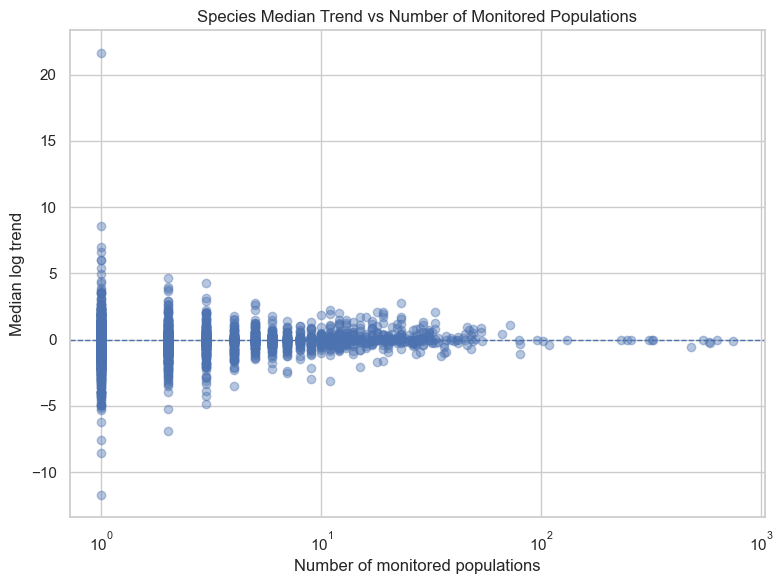

In [17]:
# Create a scatter plot showing the relationship between species monitoring coverage and median trend.
plt.figure(figsize=(8, 6))

plt.scatter(
    species_summary["Population_Count"],
    species_summary["Median_Log_Trend"],
    alpha=0.4,
)

plt.xscale("log")
plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("Number of monitored populations")
plt.ylabel("Median log trend")
plt.title("Species Median Trend vs Number of Monitored Populations")
plt.tight_layout()

# Save the figure.
plt.savefig(FIGURE_DIR / "species_trend_vs_population_count.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Save summary outputs

The final step saves the main summary tables generated in this notebook.

These files can be used later in the README, presentation, or final interpretation.

In [18]:
# Save the main risk summary tables as CSV files.
overall_risk_summary.to_csv(OUTPUT_DIR / "overall_risk_summary.csv", index=False)
class_high_risk_summary.to_csv(OUTPUT_DIR / "class_high_risk_summary.csv", index=False)
system_high_risk_summary.to_csv(OUTPUT_DIR / "system_high_risk_summary.csv", index=False)
region_high_risk_summary.to_csv(OUTPUT_DIR / "region_high_risk_summary.csv", index=False)
class_region_filtered.to_csv(OUTPUT_DIR / "class_region_high_risk_summary.csv", index=False)
well_monitored_species.to_csv(OUTPUT_DIR / "well_monitored_species_summary.csv", index=False)

# Confirm that all outputs were saved.
print("Saved summary outputs to:")
print(OUTPUT_DIR.resolve())

Saved summary outputs to:
/Users/chintamany/Documents/living-planet-index-project/outputs


## 11. Notebook conclusion

This notebook shows that risk is not evenly distributed across vertebrate classes, ecosystem systems, or regions.

The analysis stays consistent by using one population-level risk classification throughout the notebook. The species-level table is treated as supplementary and does not introduce a second risk system.

The next notebook moves from broad regional summaries to spatial analysis using latitude and longitude coordinates.